In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1. Data Extraction

# Load dataset
file_path = "smsspamcollection.txt"

df = pd.read_csv(
    "D:/Mini_project_2/Email_spam/sms+spam+collection/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"]
)

NameError: name 'pd' is not defined

: 

In [3]:
# 2. Exploratory Data Analysis (EDA)

# Preview data
print(df.head())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
# Check unique labels
print(df["label"].unique())

['ham' 'spam']


In [5]:
#Feature Engineering

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"])  # Convert text → numerical features


In [6]:
# 5. Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],      # raw text (will be vectorized later)
    df["label"],
    test_size=0.2,
    random_state=42
)

In [7]:
# 6. Feature Transformation (after split)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [8]:
# 7. Model Training

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [9]:
# 8. Validation Check (basic)

print(y_train.isna().sum())  # Ensure no missing labels

0


In [10]:
# 10. Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred, pos_label='spam')
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred, pos_label='spam')
print("Recall:", recall)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9856502242152466
Precision: 1.0
Recall: 0.8926174496644296
Confusion Matrix:
 [[966   0]
 [ 16 133]]

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.89      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



AUC Score: 0.9897


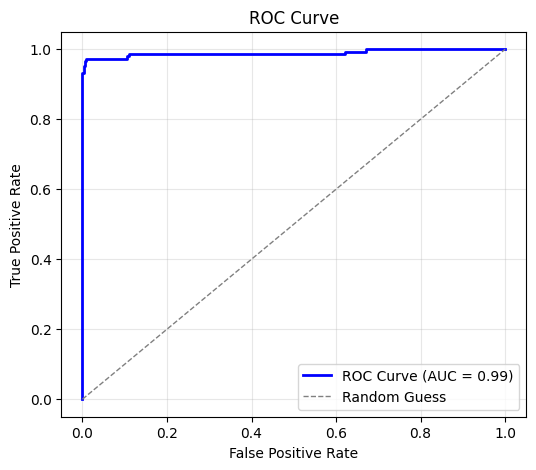

In [11]:
# 11. ROC Curve & AUC Score

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure model supports predict_proba
y_prob = model.predict_proba(X_test_vec)[:, 1]

# ROC inputs must be binary (0/1)
# If already encoded, this is fine; otherwise ensure:
# y_test_encoded = y_test.map({'ham': 0, 'spam': 1})

# Compute ROC curve
y_test_encoded = y_test.map({'ham': 0, 'spam': 1})
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

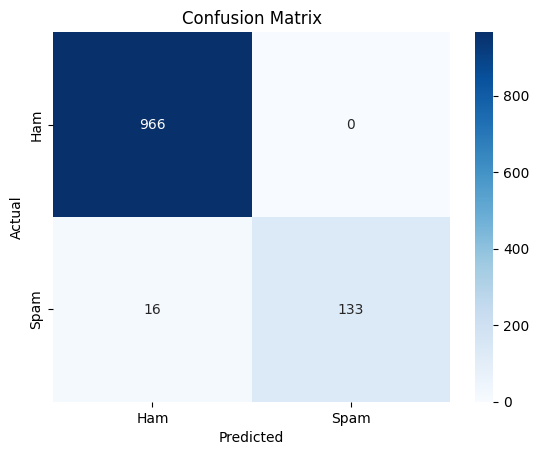

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Average Precision (AP): 0.9821929225486855


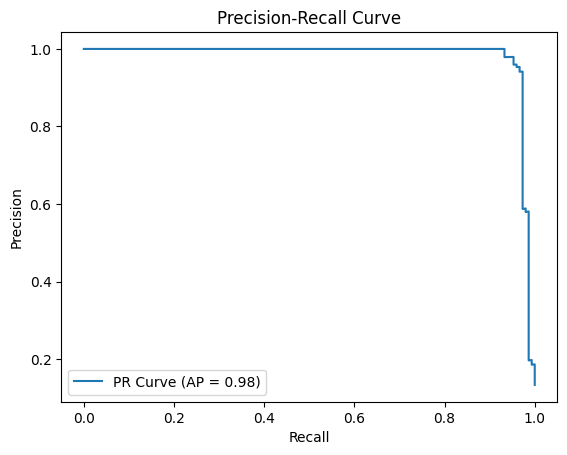

In [13]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probability scores
y_prob = model.predict_proba(X_test_vec)[:, 1]

# Compute Precision-Recall values
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_encoded, y_prob)

# Compute Average Precision (AP score)
ap_score = average_precision_score(y_test_encoded, y_prob)
print("Average Precision (AP):", ap_score)

# Plot Precision-Recall Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall_vals, precision_vals, label=f"PR Curve (AP = {ap_score:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [14]:
# Model Comparison (Classical ML)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("Accuracy:", acc)


Logistic Regression
Accuracy: 0.9856502242152466

SVM
Accuracy: 0.9856502242152466

Random Forest
Accuracy: 0.979372197309417


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
[[966   0]
 [ 16 133]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.89      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115


SVM
[[966   0]
 [ 16 133]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.89      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115


Random Forest
[[966   0]
 [ 21 128]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg      

In [16]:
# LSTM Model

from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Convert to float (for TensorFlow)
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [17]:
# LSTM Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Build LSTM Model
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
#model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=32)

#Use Early Stopping (best solution)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

# Evaluate
loss, acc = model_lstm.evaluate(X_test_pad, y_test)
print("LSTM Accuracy:", acc)

#reduce overfitting
from tensorflow.keras.layers import Dropout
model_lstm = Sequential([
    Embedding(5000, 64, input_length=max_len),
    LSTM(64),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])


Epoch 1/10


C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9367 - loss: 0.1865 - val_accuracy: 0.9794 - val_loss: 0.0647
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9886 - loss: 0.0432 - val_accuracy: 0.9901 - val_loss: 0.0393
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9951 - loss: 0.0210 - val_accuracy: 0.9919 - val_loss: 0.0405
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9978 - loss: 0.0097 - val_accuracy: 0.9919 - val_loss: 0.0398
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9901 - loss: 0.0393
LSTM Accuracy: 0.9901345372200012


In [18]:
#Regularization
from tensorflow.keras import regularizers

LSTM(64, kernel_regularizer=regularizers.l2(0.01))

<LSTM name=lstm_2, built=False>

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Get probabilities
y_pred_prob = model_lstm.predict(X_test_pad)

# Convert probabilities → class labels (0/1)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Flatten (important for sklearn)
y_pred = y_pred.flatten()

# Print results
print("\nLSTM Model")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

LSTM Model
[[262 704]
 [ 63  86]]
              precision    recall  f1-score   support

         0.0       0.81      0.27      0.41       966
         1.0       0.11      0.58      0.18       149

    accuracy                           0.31      1115
   macro avg       0.46      0.42      0.29      1115
weighted avg       0.71      0.31      0.38      1115



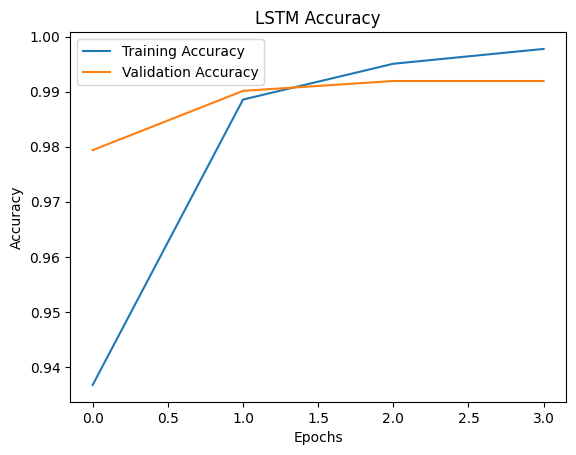

In [20]:
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM Accuracy')
plt.legend()
plt.show()

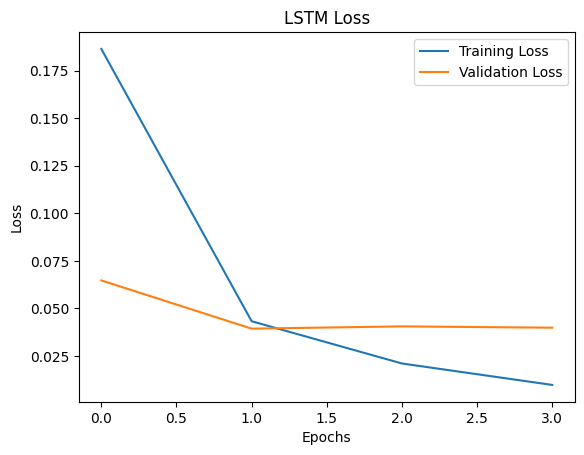

In [21]:
# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Loss')
plt.legend()
plt.show()

Naive Bayes Accuracy: 0.9883408071748879

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       966
         1.0       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



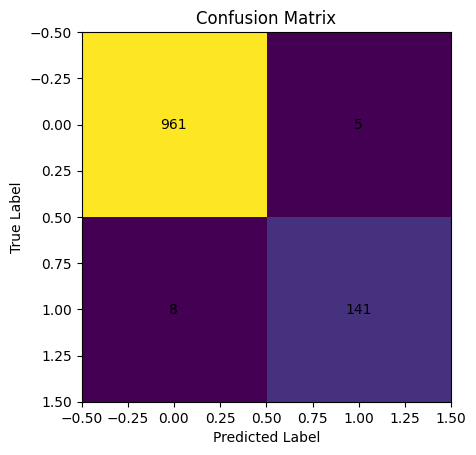

In [22]:
# =========================
# Naive Bayes Model
# =========================
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train_vec, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_vec)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
#print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Base models
estimators = [
    ('nb', MultinomialNB()),
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

# Meta model
meta_model = LogisticRegression()

# Stacking model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    stack_method='predict_proba',  # important
    cv=5
)

# Train
stack_model.fit(X_train_vec, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test_vec)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nReport:\n", classification_report(y_test, y_pred_stack))

Stacking Accuracy: 0.9937219730941704

Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       966
         1.0       1.00      0.95      0.98       149

    accuracy                           0.99      1115
   macro avg       1.00      0.98      0.99      1115
weighted avg       0.99      0.99      0.99      1115



In [25]:
import joblib

# Save trained model
joblib.dump(stack_model, "spam_stacking_model.pkl")

# Save vectorizer too
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model exported successfully!")

Model exported successfully!
